# Competing Risks HTE Examples: Heterogeneous Treatment Effects with Multiple Causes of Failure

This notebook demonstrates CATE estimation when subjects can experience one of multiple competing events (e.g. cause 1 = relapse, cause 2 = death without relapse). The estimand is the difference in **Restricted Mean Time Lost (RMTL)** for cause j:

$$\text{CATE}(X) = \text{RMTL}_j(a\!=\!1 \mid X, \tau) - \text{RMTL}_j(a\!=\!0 \mid X, \tau), \quad \text{RMTL}_j = \int_0^\tau F_j(t) \, dt$$

Two approaches:
1. **Approach A — Direct competing risk metalearners**: Fit cause-specific survival models on raw `(event, time)` data
2. **Approach B — RMTL CUT transforms + generic learners**: Transform censored competing-risk outcomes into scalar pseudo-outcomes, then use any standard CATE estimator

The DGP mirrors `original/simulation/competing/competing_hte_simulation_case1.R`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# EconML imports
from econml.metalearners._censor_metalearners import (
    TLearner, SLearner, XLearner,
    CompetingRisksTLearner, CompetingRisksSLearner,
    SeparableDirectAstar1TLearner, SeparableIndirectAstar1TLearner,
    SeparableDirectAstar1SLearner, SeparableIndirectAstar1SLearner,
    IPTWLearner, AIPTWLearner, MCLearner, MCEALearner,
    ULearner, RALearner, RLearner, IFLearner,
)
from econml.grf import GRFCausalForest as CausalForest
from econml.censor import (
    fit_nuisance_competing_crossfit,
    ipcw_cut_rmtlj, bj_cut_rmtlj, aipcw_cut_rmtlj,
    aipcw_cut_rmtlj_sep_direct_astar1, aipcw_cut_rmtlj_sep_indirect_astar1,
    uif_diff_rmtlj,
    uif_diff_rmtlj_sep_direct_astar1, uif_diff_rmtlj_sep_indirect_astar1,
)

# DGP (ported from R simulation)
from econml.tests.test_censor.dgp import make_competing_data

%matplotlib inline


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Generating Process

Competing risks DGP with:
- 6 covariates (3 correlated continuous, 3 binary)
- Logistic propensity score (same as survival DGP)
- Two exponential cause times with covariate-dependent rates
- Treatment-dependent censoring
- Event codes: 0 = censored, 1 = cause 1 (primary), 2 = cause 2 (competing)
- True CATE via Monte Carlo: total, separable direct, separable indirect

In [2]:
tau = 4.0
data = make_competing_data(n=4000, tau=tau, seed=42, compute_true_cate=True)

X = data['X']
T = data['T']
time = data['time']
event = data['event']       # 0=censored, 1=cause1, 2=cause2
competing_obj = data['Y']        # structured array for competing risk learners
true_cate_total = data['true_cate_total']
true_cate_direct = data['true_cate_direct']
true_cate_indirect = data['true_cate_indirect']

clip_hte = lambda y: np.clip(np.asarray(y, dtype=float).ravel(), -2 * tau, 2 * tau)

n = len(T)
print(f"n={n}, d={X.shape[1]}, tau={tau}")
print(f"Treatment rate: {T.mean():.2f}")
print(f"Event rates — censored: {(event==0).mean():.2f}, cause 1: {(event==1).mean():.2f}, cause 2: {(event==2).mean():.2f}")
print(f"True ATE (total):    {true_cate_total.mean():.4f}")
print(f"True ATE (direct):   {true_cate_direct.mean():.4f}")
print(f"True ATE (indirect): {true_cate_indirect.mean():.4f}")

n=4000, d=6, tau=4.0
Treatment rate: 0.49
Event rates — censored: 0.10, cause 1: 0.48, cause 2: 0.42
True ATE (total):    0.1315
True ATE (direct):   0.0958
True ATE (indirect): 0.0357


## 2. Approach A — Direct Competing Risk Metalearners

These take raw `(event, time)` structured arrays with multi-cause event codes. They fit overall survival S(t), cause-j survival S_j(t), and optionally competing S_jbar(t) internally.

### 2a. Total effect (RMTL difference)

In [3]:
# CompetingRisksSLearner (cross-fitted): pooled models with [a, X, a*X] features
cr_s = CompetingRisksSLearner(
    tau=tau,
)
cr_s.fit(competing_obj, T, X=X)
cate_cr_s = clip_hte(cr_s.effect(X))

# CompetingRisksTLearner (cross-fitted): separate models per arm
cr_t = CompetingRisksTLearner(
    tau=tau,
)
cr_t.fit(competing_obj, T, X=X)
cate_cr_t = clip_hte(cr_t.effect(X))

print(f"CompetingRisksSLearner ATE: {cate_cr_s.mean():.4f}")
print(f"CompetingRisksTLearner ATE: {cate_cr_t.mean():.4f}")


CompetingRisksSLearner ATE: 0.1286
CompetingRisksTLearner ATE: 0.1207


### 2b. Separable effects (direct + indirect)

Decompose the total effect into:
- **Direct**: effect of treatment on cause j holding competing hazard at reference (a*=1)
- **Indirect**: effect via competing cause pathway

Requires an additional `models_competing` for the competing cause survival.

In [4]:
# CompetingRisksSLearner with separable effects (cross-fitted)
cr_s_sep_direct = SeparableDirectAstar1SLearner(
    tau=tau,
)
cr_s_sep_direct.fit(competing_obj, T, X=X)
direct_astar1_cr_s = clip_hte(cr_s_sep_direct.effect(X))

cr_s_sep_indirect = SeparableIndirectAstar1SLearner(
    tau=tau,
)
cr_s_sep_indirect.fit(competing_obj, T, X=X)
indirect_astar1_cr_s = clip_hte(cr_s_sep_indirect.effect(X))

# CompetingRisksTLearner with separable effects (cross-fitted)
cr_t_sep_direct = SeparableDirectAstar1TLearner(
    tau=tau,
)
cr_t_sep_direct.fit(competing_obj, T, X=X)
direct_astar1_cr_t = clip_hte(cr_t_sep_direct.effect(X))

cr_t_sep_indirect = SeparableIndirectAstar1TLearner(
    tau=tau,
)
cr_t_sep_indirect.fit(competing_obj, T, X=X)
indirect_astar1_cr_t = clip_hte(cr_t_sep_indirect.effect(X))

print(f"{'':30s} {'Direct ATE':>12s} {'Indirect ATE':>14s}  (true: {true_cate_direct.mean():.4f} / {true_cate_indirect.mean():.4f})")
print(f"{'SeparableAstar1SLearners':30s} {direct_astar1_cr_s.mean():12.4f} {indirect_astar1_cr_s.mean():14.4f}")
print(f"{'SeparableAstar1TLearners':30s} {direct_astar1_cr_t.mean():12.4f} {indirect_astar1_cr_t.mean():14.4f}")
print(f"Sum check (S): {(direct_astar1_cr_s + indirect_astar1_cr_s).mean():.4f}  (T): {(direct_astar1_cr_t + indirect_astar1_cr_t).mean():.4f}  (total: {true_cate_total.mean():.4f})")


                                 Direct ATE   Indirect ATE  (true: 0.0958 / 0.0357)
SeparableAstar1SLearners             0.0868         0.0344
SeparableAstar1TLearners             0.0780         0.0442
Sum check (S): 0.1212  (T): 0.1222  (total: 0.1315)


## 3. Approach B — RMTL CUT Transforms + Generic Learners

### 3a. Cross-fit nuisance models and apply RMTL transforms


In [5]:
# Cross-fit all 4 nuisance model types: G, S, Sj, Sjbar, plus ps(X)
nuis = fit_nuisance_competing_crossfit(
    time, event, T, X,
    cause=1,
    cv=2,
    random_state=42)

print(f"Time grid: {len(nuis.time_grid)} points")
print(f"Matrices fitted: G={nuis.G_a0 is not None}, S={nuis.S_a0 is not None}, "
      f"Sj={nuis.Sj_a0 is not None}, Sjbar={nuis.Sjbar_a0 is not None}")
print(f"ps range: [{nuis.ps.min():.4f}, {nuis.ps.max():.4f}]")


Time grid: 767 points
Matrices fitted: G=True, S=True, Sj=True, Sjbar=True
ps range: [0.0431, 0.9531]


In [6]:
# RMTL CUT transforms for total effect
tg = nuis.time_grid

Y_ipcw_total = ipcw_cut_rmtlj(T, time, event, tau, nuis.G_a0, nuis.G_a1,
                               cause=1, time_grid=tg)

Y_bj_total = bj_cut_rmtlj(T, time, event, tau, nuis.S_a0, nuis.S_a1,
                           nuis.Sj_a0, nuis.Sj_a1, cause=1, time_grid=tg)

Y_aipcw_total = aipcw_cut_rmtlj(T, time, event, tau,
                                 nuis.G_a0, nuis.G_a1,
                                 nuis.S_a0, nuis.S_a1,
                                 nuis.Sj_a0, nuis.Sj_a1,
                                 cause=1, time_grid=tg)

print(f"IPCW RMTL pseudo-outcome:  mean={Y_ipcw_total.mean():.4f}")
print(f"BJ RMTL pseudo-outcome:    mean={Y_bj_total.mean():.4f}")
print(f"AIPCW RMTL pseudo-outcome: mean={Y_aipcw_total.mean():.4f}")

# RMTL CUT transforms for separable effects (IPCW not available for separable effects)
n_t = nuis.G_a0.shape[0]
n_times = nuis.G_a0.shape[1]
G_ones = np.ones((n_t, n_times))

# BJ separable pseudo-outcomes: singly robust (G=1 identity)
Y_bj_sep_direct_astar1 = aipcw_cut_rmtlj_sep_direct_astar1(
    T, time, event, tau,
    G_ones, G_ones, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)

Y_bj_sep_indirect_astar1 = aipcw_cut_rmtlj_sep_indirect_astar1(
    T, time, event, tau,
    G_ones, G_ones, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)

# AIPCW separable pseudo-outcomes: doubly robust (recommended)
Y_aipcw_sep_direct_astar1 = aipcw_cut_rmtlj_sep_direct_astar1(
    T, time, event, tau,
    nuis.G_a0, nuis.G_a1, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)

Y_aipcw_sep_indirect_astar1 = aipcw_cut_rmtlj_sep_indirect_astar1(
    T, time, event, tau,
    nuis.G_a0, nuis.G_a1, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)

print(f"BJ    separable direct   pseudo-outcome: mean={Y_bj_sep_direct_astar1.mean():.4f}")
print(f"BJ    separable indirect pseudo-outcome: mean={Y_bj_sep_indirect_astar1.mean():.4f}")
print(f"AIPCW separable direct   pseudo-outcome: mean={Y_aipcw_sep_direct_astar1.mean():.4f}")
print(f"AIPCW separable indirect pseudo-outcome: mean={Y_aipcw_sep_indirect_astar1.mean():.4f}")

IPCW RMTL pseudo-outcome:  mean=0.9599
BJ RMTL pseudo-outcome:    mean=0.9598
AIPCW RMTL pseudo-outcome: mean=0.9583
BJ    separable direct   pseudo-outcome: mean=1.3685
BJ    separable indirect pseudo-outcome: mean=0.9230
AIPCW separable direct   pseudo-outcome: mean=1.3752
AIPCW separable indirect pseudo-outcome: mean=0.9233


### 3b. Feed RMTL pseudo-outcomes into generic learners

After the CUT step, `Y_star` is a plain float array. Any existing EconML estimator works directly.

**Total effect** (`Y_aipcw_total`, doubly robust — recommended):
- `Y_ipcw_total` and `Y_bj_total` are also available as singly-robust alternatives.

**Separable effects** (`Y_aipcw_sep_direct_astar1`, `Y_aipcw_sep_indirect_astar1`, doubly robust — recommended):
- `Y_bj_sep_direct_astar1` and `Y_bj_sep_indirect_astar1` are available as singly-robust alternatives.

In [7]:
results = {}

# --- Total effect (Y_aipcw_total) ---
t_est = TLearner(cv=2)
t_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + TLearner'] = clip_hte(t_est.effect(X))

s_est = SLearner(cv=2)
s_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + SLearner'] = clip_hte(s_est.effect(X))

cf_est = CausalForest(num_trees=200, seed=42)
cf_est.fit(X, Y_aipcw_total, T)
results['AIPCW + CausalForest'] = clip_hte(cf_est.effect(X))

print("ATEs (total effect):")
for k in ['AIPCW + TLearner', 'AIPCW + SLearner', 'AIPCW + CausalForest']:
    print(f"  {k:40s}: {results[k].mean():.4f}")

# --- Separable direct effect (Y_aipcw_sep_direct_astar1) ---
t_sep_d = TLearner(cv=2)
t_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + TLearner'] = clip_hte(t_sep_d.effect(X))

s_sep_d = SLearner(cv=2)
s_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + SLearner'] = clip_hte(s_sep_d.effect(X))

cf_sep_d = CausalForest(num_trees=200, seed=42)
cf_sep_d.fit(X, Y_aipcw_sep_direct_astar1, T)
results['AIPCW sep direct + CausalForest'] = clip_hte(cf_sep_d.effect(X))

print("ATEs (separable direct, true={:.4f}):".format(true_cate_direct.mean()))
for k in ['AIPCW sep direct + TLearner', 'AIPCW sep direct + SLearner',
          'AIPCW sep direct + CausalForest']:
    print(f"  {k:40s}: {results[k].mean():.4f}")

# --- Separable indirect effect (Y_aipcw_sep_indirect_astar1) ---
t_sep_i = TLearner(cv=2)
t_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + TLearner'] = clip_hte(t_sep_i.effect(X))

s_sep_i = SLearner(cv=2)
s_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + SLearner'] = clip_hte(s_sep_i.effect(X))

cf_sep_i = CausalForest(num_trees=200, seed=42)
cf_sep_i.fit(X, Y_aipcw_sep_indirect_astar1, T)
results['AIPCW sep indirect + CausalForest'] = clip_hte(cf_sep_i.effect(X))

print("ATEs (separable indirect, true={:.4f}):".format(true_cate_indirect.mean()))
for k in ['AIPCW sep indirect + TLearner', 'AIPCW sep indirect + SLearner',
          'AIPCW sep indirect + CausalForest']:
    print(f"  {k:40s}: {results[k].mean():.4f}")


ATEs (total effect):
  AIPCW + TLearner                        : 0.1028
  AIPCW + SLearner                        : 0.1543
  AIPCW + CausalForest                    : 0.1205
ATEs (separable direct, true=0.0958):
  AIPCW sep direct + TLearner             : 0.0250
  AIPCW sep direct + SLearner             : 0.1212
  AIPCW sep direct + CausalForest         : -0.0185
ATEs (separable indirect, true=0.0357):
  AIPCW sep indirect + TLearner           : 0.0380
  AIPCW sep indirect + SLearner           : 0.0739
  AIPCW sep indirect + CausalForest       : 0.0875


### 3c. IFLearner (Uncentered Influence Function)

The UIF transforms produce per-subject pseudo-outcomes:
- `uif_diff_rmtlj` → total RMTL effect
- `uif_diff_rmtlj_sep_direct_astar1` → separable direct effect
- `uif_diff_rmtlj_sep_indirect_astar1` → separable indirect effect

`IFLearner` regresses each UIF score vector on X to estimate CATE(X) — mirroring `uif_learner()` from `hte_learners.R`.
Here the balancing, tilting, and separable-effect propensity inputs all come from the cross-fitted nuisance step.
The raw UIF scores (`IF`) are also kept as a reference (population-level, no second-stage regression).


In [8]:
# UIF: use cross-fitted balancing weights, tilting weights, and propensity scores
ps = nuis.ps
bw = nuis.iptw
tilt = nuis.naive

# --- Total effect ---
Y_uif_diff_total = uif_diff_rmtlj(T, time, event, tau, bw, tilt,
                                         nuis.G_a0, nuis.G_a1,
                                         nuis.S_a0, nuis.S_a1,
                                         nuis.Sj_a0, nuis.Sj_a1,
                                         cause=1, time_grid=tg)
if_total = IFLearner(cv=2)
if_total.fit(Y_uif_diff_total, X=X)
results['IFLearner (total)'] = clip_hte(if_total.effect(X))
raw_if_total = Y_uif_diff_total

# --- Separable direct effect ---
Y_uif_diff_sep_direct_astar1 = uif_diff_rmtlj_sep_direct_astar1(
    T, ps, time, event, tau, bw, tilt,
    nuis.G_a0, nuis.G_a1, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)
if_sep_d = IFLearner(cv=2)
if_sep_d.fit(Y_uif_diff_sep_direct_astar1, X=X)
results['IFLearner (sep direct)'] = clip_hte(if_sep_d.effect(X))
raw_if_sep_direct = Y_uif_diff_sep_direct_astar1

# --- Separable indirect effect ---
Y_uif_diff_sep_indirect_astar1 = uif_diff_rmtlj_sep_indirect_astar1(
    T, ps, time, event, tau, bw, tilt,
    nuis.G_a0, nuis.G_a1, nuis.S_a0, nuis.S_a1,
    nuis.Sj_a0, nuis.Sj_a1, nuis.Sjbar_a0, nuis.Sjbar_a1,
    cause=1, time_grid=tg)
if_sep_i = IFLearner(cv=2)
if_sep_i.fit(Y_uif_diff_sep_indirect_astar1, X=X)
results['IFLearner (sep indirect)'] = clip_hte(if_sep_i.effect(X))
raw_if_sep_indirect = Y_uif_diff_sep_indirect_astar1

print(f"IFLearner ATE (total):        {results['IFLearner (total)'].mean():.4f}  (true: {true_cate_total.mean():.4f})")
print(f"IFLearner ATE (sep direct):   {results['IFLearner (sep direct)'].mean():.4f}  (true: {true_cate_direct.mean():.4f})")
print(f"IFLearner ATE (sep indirect): {results['IFLearner (sep indirect)'].mean():.4f}  (true: {true_cate_indirect.mean():.4f})")
print(f"Raw IF ATE (total):           {raw_if_total.mean():.4f}")
print(f"Raw IF ATE (sep direct):      {raw_if_sep_direct.mean():.4f}")
print(f"Raw IF ATE (sep indirect):    {raw_if_sep_indirect.mean():.4f}")


IFLearner ATE (total):        0.1531  (true: 0.1315)
IFLearner ATE (sep direct):   -0.3350  (true: 0.0958)
IFLearner ATE (sep indirect): 0.4380  (true: 0.0357)
Raw IF ATE (total):           0.0693
Raw IF ATE (sep direct):      -0.3278
Raw IF ATE (sep indirect):    0.3971


## 4. Approach C — CUT Transforms + Outcome-Transform Learners

XLearner, AIPTWLearner, RLearner, IPTW, MC, MCEA, U-learner build their own internal pseudo-outcomes on top of the AIPCW RMTL pseudo-outcome `Y*`.

### 4a total effect

In [9]:
# XLearner (cross-fitted; ≈ x_learner): propensity-weighted cross-residuals
x_est = XLearner(cv=2)
x_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + XLearner'] = clip_hte(x_est.effect(X))

# AIPTWLearner (≈ aiptw_learner): doubly robust pseudo-outcome with cross-fitting
aiptw_est = AIPTWLearner(cv=2)
aiptw_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + AIPTWLearner'] = clip_hte(aiptw_est.effect(X))

# RLearner (≈ r_learner): weighted U-style regression with cross-fitting
r_est = RLearner(cv=2)
r_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + RLearner'] = clip_hte(r_est.effect(X))

# IPTWLearner (cross-fitted; ≈ iptw_learner): phi = Y* * (A/e - (1-A)/(1-e)), regress on X
iptw_est = IPTWLearner(cv=2)
iptw_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + IPTWLearner'] = clip_hte(iptw_est.effect(X))

# MCLearner (cross-fitted; ≈ mc_learner): phi = 2*(2A-1)*Y*, propensity-weighted regression
mc_est = MCLearner(cv=2)
mc_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + MCLearner'] = clip_hte(mc_est.effect(X))

# MCEALearner (cross-fitted; ≈ mcea_learner): residual-augmented MC, propensity-weighted regression
mcea_est = MCEALearner(cv=2)
mcea_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + MCEALearner'] = clip_hte(mcea_est.effect(X))

# ULearner (cross-fitted; ≈ u_learner): phi = (Y* - e*mu1 - (1-e)*mu0) / (A - e), regress on X
u_est = ULearner(cv=2)
u_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + ULearner'] = clip_hte(u_est.effect(X))

# RALearner (cross-fitted; ≈ ra_learner): phi = A*(Y* - mu0) + (1-A)*(mu1 - Y*), regress on X
ra_est = RALearner(cv=2)
ra_est.fit(Y_aipcw_total, T, X=X)
results['AIPCW + RALearner'] = clip_hte(ra_est.effect(X))

print("Approach C ATEs:")
for k in ['AIPCW + XLearner', 'AIPCW + AIPTWLearner', 'AIPCW + RLearner',
          'AIPCW + IPTWLearner', 'AIPCW + MCLearner',
          'AIPCW + MCEALearner', 'AIPCW + ULearner', 'AIPCW + RALearner']:
    print(f"  {k:30s}: {results[k].mean():.4f}")


Approach C ATEs:
  AIPCW + XLearner              : 0.1227
  AIPCW + AIPTWLearner          : 0.0830
  AIPCW + RLearner              : 0.0941
  AIPCW + IPTWLearner           : 0.1037
  AIPCW + MCLearner             : 0.1407
  AIPCW + MCEALearner           : 0.1218
  AIPCW + ULearner              : 0.0849
  AIPCW + RALearner             : 0.1225


### 4b separable direct effect

In [10]:
# XLearner (cross-fitted)
x_sep_d = XLearner(cv=2)
x_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + XLearner'] = clip_hte(x_sep_d.effect(X))

# AIPTWLearner
aiptw_sep_d = AIPTWLearner(cv=2)
aiptw_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + AIPTWLearner'] = clip_hte(aiptw_sep_d.effect(X))

# RLearner
r_sep_d = RLearner(cv=2)
r_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + RLearner'] = clip_hte(r_sep_d.effect(X))

# IPTWLearner (cross-fitted)
iptw_sep_d = IPTWLearner(cv=2)
iptw_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + IPTWLearner'] = clip_hte(iptw_sep_d.effect(X))

# MCLearner (cross-fitted)
mc_sep_d = MCLearner(cv=2)
mc_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + MCLearner'] = clip_hte(mc_sep_d.effect(X))

# MCEALearner (cross-fitted)
mcea_sep_d = MCEALearner(cv=2)
mcea_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + MCEALearner'] = clip_hte(mcea_sep_d.effect(X))

# ULearner (cross-fitted)
u_sep_d = ULearner(cv=2)
u_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + ULearner'] = clip_hte(u_sep_d.effect(X))

# RALearner (cross-fitted)
ra_sep_d = RALearner(cv=2)
ra_sep_d.fit(Y_aipcw_sep_direct_astar1, T, X=X)
results['AIPCW sep direct + RALearner'] = clip_hte(ra_sep_d.effect(X))

print(f"ATEs (separable direct, true={true_cate_direct.mean():.4f}):")
for k in ['AIPCW sep direct + XLearner', 'AIPCW sep direct + AIPTWLearner',
          'AIPCW sep direct + RLearner', 'AIPCW sep direct + IPTWLearner',
          'AIPCW sep direct + MCLearner', 'AIPCW sep direct + MCEALearner',
          'AIPCW sep direct + ULearner', 'AIPCW sep direct + RALearner']:
    print(f"  {k:40s}: {results[k].mean():.4f}")


ATEs (separable direct, true=0.0958):
  AIPCW sep direct + XLearner             : -0.0254
  AIPCW sep direct + AIPTWLearner         : -0.0140
  AIPCW sep direct + RLearner             : 0.0753
  AIPCW sep direct + IPTWLearner          : 0.1133
  AIPCW sep direct + MCLearner            : 0.0653
  AIPCW sep direct + MCEALearner          : -0.0473
  AIPCW sep direct + ULearner             : 0.0938
  AIPCW sep direct + RALearner            : -0.0151


### 4c separable indirect effect

In [11]:
# XLearner (cross-fitted)
x_sep_i = XLearner(cv=2)
x_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + XLearner'] = clip_hte(x_sep_i.effect(X))

# AIPTWLearner
aiptw_sep_i = AIPTWLearner(cv=2)
aiptw_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + AIPTWLearner'] = clip_hte(aiptw_sep_i.effect(X))

# RLearner
r_sep_i = RLearner(cv=2)
r_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + RLearner'] = clip_hte(r_sep_i.effect(X))

# IPTWLearner (cross-fitted)
iptw_sep_i = IPTWLearner(cv=2)
iptw_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + IPTWLearner'] = clip_hte(iptw_sep_i.effect(X))

# MCLearner (cross-fitted)
mc_sep_i = MCLearner(cv=2)
mc_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + MCLearner'] = clip_hte(mc_sep_i.effect(X))

# MCEALearner (cross-fitted)
mcea_sep_i = MCEALearner(cv=2)
mcea_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + MCEALearner'] = clip_hte(mcea_sep_i.effect(X))

# ULearner (cross-fitted)
u_sep_i = ULearner(cv=2)
u_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + ULearner'] = clip_hte(u_sep_i.effect(X))

# RALearner (cross-fitted)
ra_sep_i = RALearner(cv=2)
ra_sep_i.fit(Y_aipcw_sep_indirect_astar1, T, X=X)
results['AIPCW sep indirect + RALearner'] = clip_hte(ra_sep_i.effect(X))

print(f"ATEs (separable indirect, true={true_cate_indirect.mean():.4f}):")
for k in ['AIPCW sep indirect + XLearner', 'AIPCW sep indirect + AIPTWLearner',
          'AIPCW sep indirect + RLearner', 'AIPCW sep indirect + IPTWLearner',
          'AIPCW sep indirect + MCLearner', 'AIPCW sep indirect + MCEALearner',
          'AIPCW sep indirect + ULearner', 'AIPCW sep indirect + RALearner']:
    print(f"  {k:40s}: {results[k].mean():.4f}")


ATEs (separable indirect, true=0.0357):
  AIPCW sep indirect + XLearner           : 0.0702
  AIPCW sep indirect + AIPTWLearner       : 0.0529
  AIPCW sep indirect + RLearner           : 0.0891
  AIPCW sep indirect + IPTWLearner        : -0.0058
  AIPCW sep indirect + MCLearner          : -0.0257
  AIPCW sep indirect + MCEALearner        : 0.0462
  AIPCW sep indirect + ULearner           : 0.0785
  AIPCW sep indirect + RALearner          : 0.0615


## 5. Evaluation & Comparison

In [12]:
# Collect learner-only CATE estimates for each estimand
total_results = {
    'CompetingRisksTLearner': np.asarray(cate_cr_t).ravel(),
    'CompetingRisksSLearner': np.asarray(cate_cr_s).ravel(),
    'AIPCW + TLearner': np.asarray(results['AIPCW + TLearner']).ravel(),
    'AIPCW + SLearner': np.asarray(results['AIPCW + SLearner']).ravel(),
    'AIPCW + CausalForest': np.asarray(results['AIPCW + CausalForest']).ravel(),
    'IFLearner (total)': np.asarray(results['IFLearner (total)']).ravel(),
    'AIPCW + XLearner': np.asarray(results['AIPCW + XLearner']).ravel(),
    'AIPCW + AIPTWLearner': np.asarray(results['AIPCW + AIPTWLearner']).ravel(),
    'AIPCW + RLearner': np.asarray(results['AIPCW + RLearner']).ravel(),
    'AIPCW + IPTWLearner': np.asarray(results['AIPCW + IPTWLearner']).ravel(),
    'AIPCW + MCLearner': np.asarray(results['AIPCW + MCLearner']).ravel(),
    'AIPCW + MCEALearner': np.asarray(results['AIPCW + MCEALearner']).ravel(),
    'AIPCW + ULearner': np.asarray(results['AIPCW + ULearner']).ravel(),
    'AIPCW + RALearner': np.asarray(results['AIPCW + RALearner']).ravel(),
}

direct_results = {
    'SeparableDirectAstar1TLearner': np.asarray(direct_astar1_cr_t).ravel(),
    'SeparableDirectAstar1SLearner': np.asarray(direct_astar1_cr_s).ravel(),
    'AIPCW sep direct + TLearner': np.asarray(results['AIPCW sep direct + TLearner']).ravel(),
    'AIPCW sep direct + SLearner': np.asarray(results['AIPCW sep direct + SLearner']).ravel(),
    'AIPCW sep direct + CausalForest': np.asarray(results['AIPCW sep direct + CausalForest']).ravel(),
    'IFLearner (sep direct)': np.asarray(results['IFLearner (sep direct)']).ravel(),
    'AIPCW sep direct + XLearner': np.asarray(results['AIPCW sep direct + XLearner']).ravel(),
    'AIPCW sep direct + AIPTWLearner': np.asarray(results['AIPCW sep direct + AIPTWLearner']).ravel(),
    'AIPCW sep direct + RLearner': np.asarray(results['AIPCW sep direct + RLearner']).ravel(),
    'AIPCW sep direct + IPTWLearner': np.asarray(results['AIPCW sep direct + IPTWLearner']).ravel(),
    'AIPCW sep direct + MCLearner': np.asarray(results['AIPCW sep direct + MCLearner']).ravel(),
    'AIPCW sep direct + MCEALearner': np.asarray(results['AIPCW sep direct + MCEALearner']).ravel(),
    'AIPCW sep direct + ULearner': np.asarray(results['AIPCW sep direct + ULearner']).ravel(),
    'AIPCW sep direct + RALearner': np.asarray(results['AIPCW sep direct + RALearner']).ravel(),
}

indirect_results = {
    'SeparableIndirectAstar1TLearner': np.asarray(indirect_astar1_cr_t).ravel(),
    'SeparableIndirectAstar1SLearner': np.asarray(indirect_astar1_cr_s).ravel(),
    'AIPCW sep indirect + TLearner': np.asarray(results['AIPCW sep indirect + TLearner']).ravel(),
    'AIPCW sep indirect + SLearner': np.asarray(results['AIPCW sep indirect + SLearner']).ravel(),
    'AIPCW sep indirect + CausalForest': np.asarray(results['AIPCW sep indirect + CausalForest']).ravel(),
    'IFLearner (sep indirect)': np.asarray(results['IFLearner (sep indirect)']).ravel(),
    'AIPCW sep indirect + XLearner': np.asarray(results['AIPCW sep indirect + XLearner']).ravel(),
    'AIPCW sep indirect + AIPTWLearner': np.asarray(results['AIPCW sep indirect + AIPTWLearner']).ravel(),
    'AIPCW sep indirect + RLearner': np.asarray(results['AIPCW sep indirect + RLearner']).ravel(),
    'AIPCW sep indirect + IPTWLearner': np.asarray(results['AIPCW sep indirect + IPTWLearner']).ravel(),
    'AIPCW sep indirect + MCLearner': np.asarray(results['AIPCW sep indirect + MCLearner']).ravel(),
    'AIPCW sep indirect + MCEALearner': np.asarray(results['AIPCW sep indirect + MCEALearner']).ravel(),
    'AIPCW sep indirect + ULearner': np.asarray(results['AIPCW sep indirect + ULearner']).ravel(),
    'AIPCW sep indirect + RALearner': np.asarray(results['AIPCW sep indirect + RALearner']).ravel(),
}

all_truth_arrays = [true_cate_total, true_cate_direct, true_cate_indirect]
all_pred_arrays = list(total_results.values()) + list(direct_results.values()) + list(indirect_results.values())
scatter_axis_min = min(arr.min() for arr in all_truth_arrays + all_pred_arrays)
scatter_axis_max = max(arr.max() for arr in all_truth_arrays + all_pred_arrays)
scatter_lims = [scatter_axis_min, scatter_axis_max]

all_bias_arrays = (
    [np.abs(v - true_cate_total) for v in total_results.values()]
    + [np.abs(v - true_cate_direct) for v in direct_results.values()]
    + [np.abs(v - true_cate_indirect) for v in indirect_results.values()]
)
violin_ymax = max(arr.max() for arr in all_bias_arrays)
violin_xlim = (0.5, len(total_results) + 0.5)
estimate_ymin = min(arr.min() for arr in all_pred_arrays)
estimate_ymax = max(arr.max() for arr in all_pred_arrays)


def _print_metrics_table(title, cate_map, truth, truth_label):
    print(title)
    print(f"{'Method':35s} {'ATE':>8s} {'Bias':>8s} {'RMSE':>8s}")
    print('-' * 63)
    for name, cate_hat in cate_map.items():
        bias = np.mean(cate_hat - truth)
        rmse = np.sqrt(np.mean((cate_hat - truth) ** 2))
        ate = np.mean(cate_hat)
        print(f"{name:35s} {ate:8.4f} {bias:8.4f} {rmse:8.4f}")
    print(f"{truth_label:35s} {truth.mean():8.4f}")
    print()


_print_metrics_table('Total CATE estimates', total_results, true_cate_total, 'True ATE (total)')
_print_metrics_table('Separable direct CATE estimates', direct_results, true_cate_direct, 'True ATE (sep direct)')
_print_metrics_table('Separable indirect CATE estimates', indirect_results, true_cate_indirect, 'True ATE (sep indirect)')


Total CATE estimates
Method                                   ATE     Bias     RMSE
---------------------------------------------------------------
CompetingRisksTLearner                0.1207  -0.0107   0.4026
CompetingRisksSLearner                0.1286  -0.0028   0.3550
AIPCW + TLearner                      0.1028  -0.0286   0.4008
AIPCW + SLearner                      0.1543   0.0228   0.3686
AIPCW + CausalForest                  0.1205  -0.0110   0.2935
IFLearner (total)                     0.1531   0.0216   1.9732
AIPCW + XLearner                      0.1227  -0.0087   0.4131
AIPCW + AIPTWLearner                  0.0830  -0.0484   0.7979
AIPCW + RLearner                      0.0941  -0.0373   0.7194
AIPCW + IPTWLearner                   0.1037  -0.0277   0.8582
AIPCW + MCLearner                     0.1407   0.0093   0.8567
AIPCW + MCEALearner                   0.1218  -0.0097   0.7097
AIPCW + ULearner                      0.0849  -0.0466   1.0813
AIPCW + RALearner                

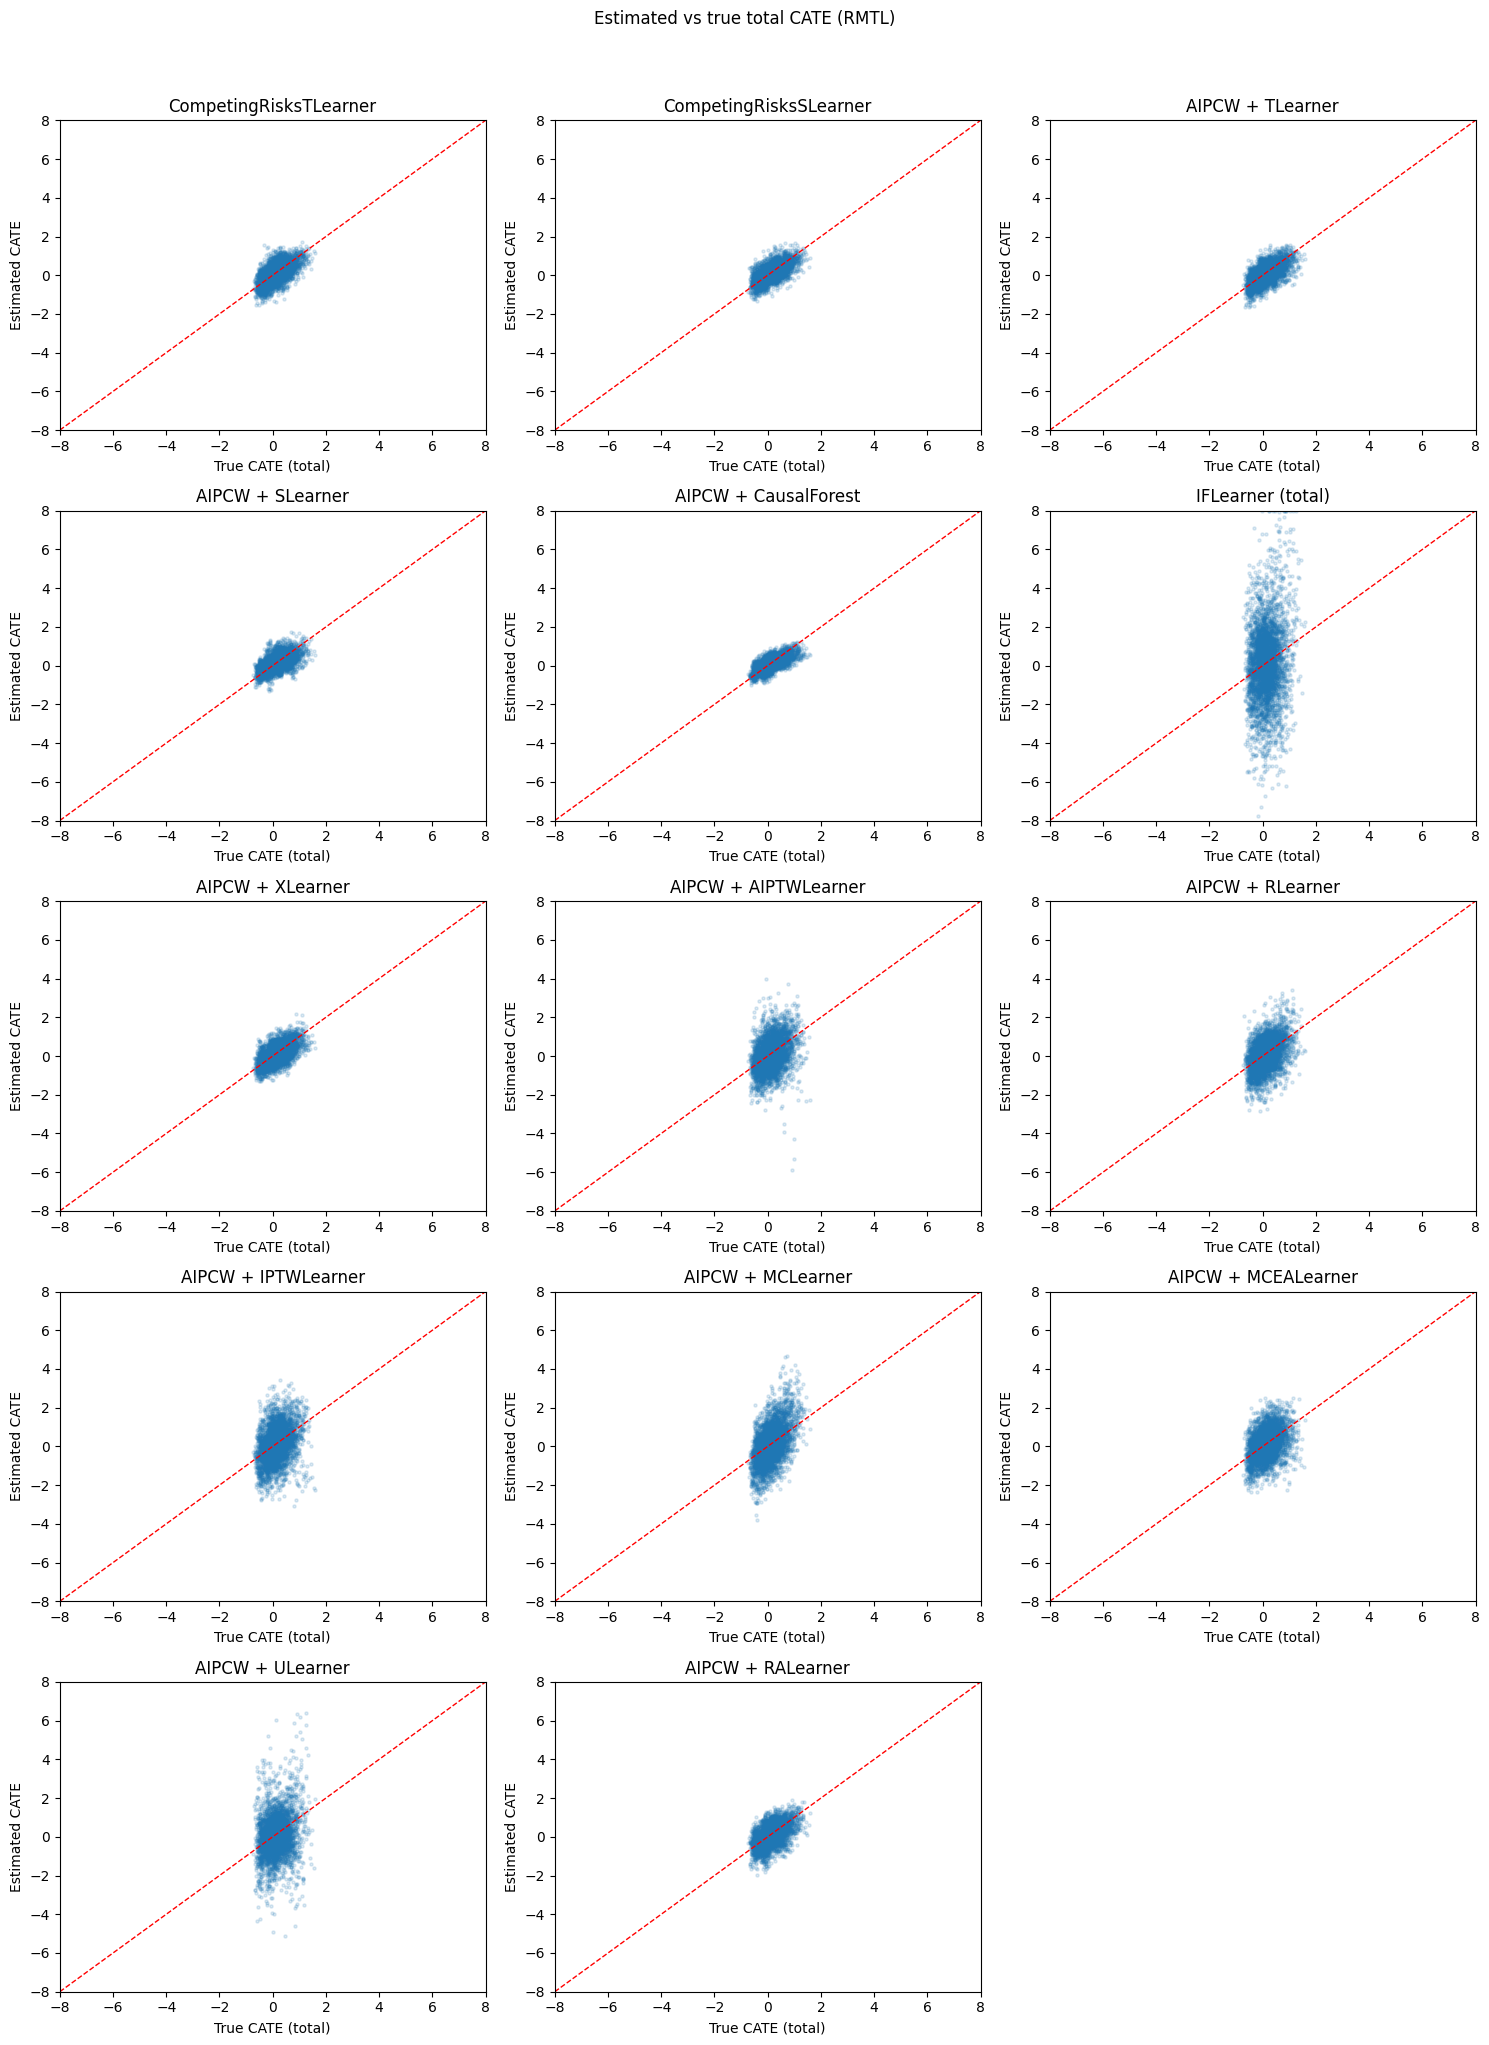

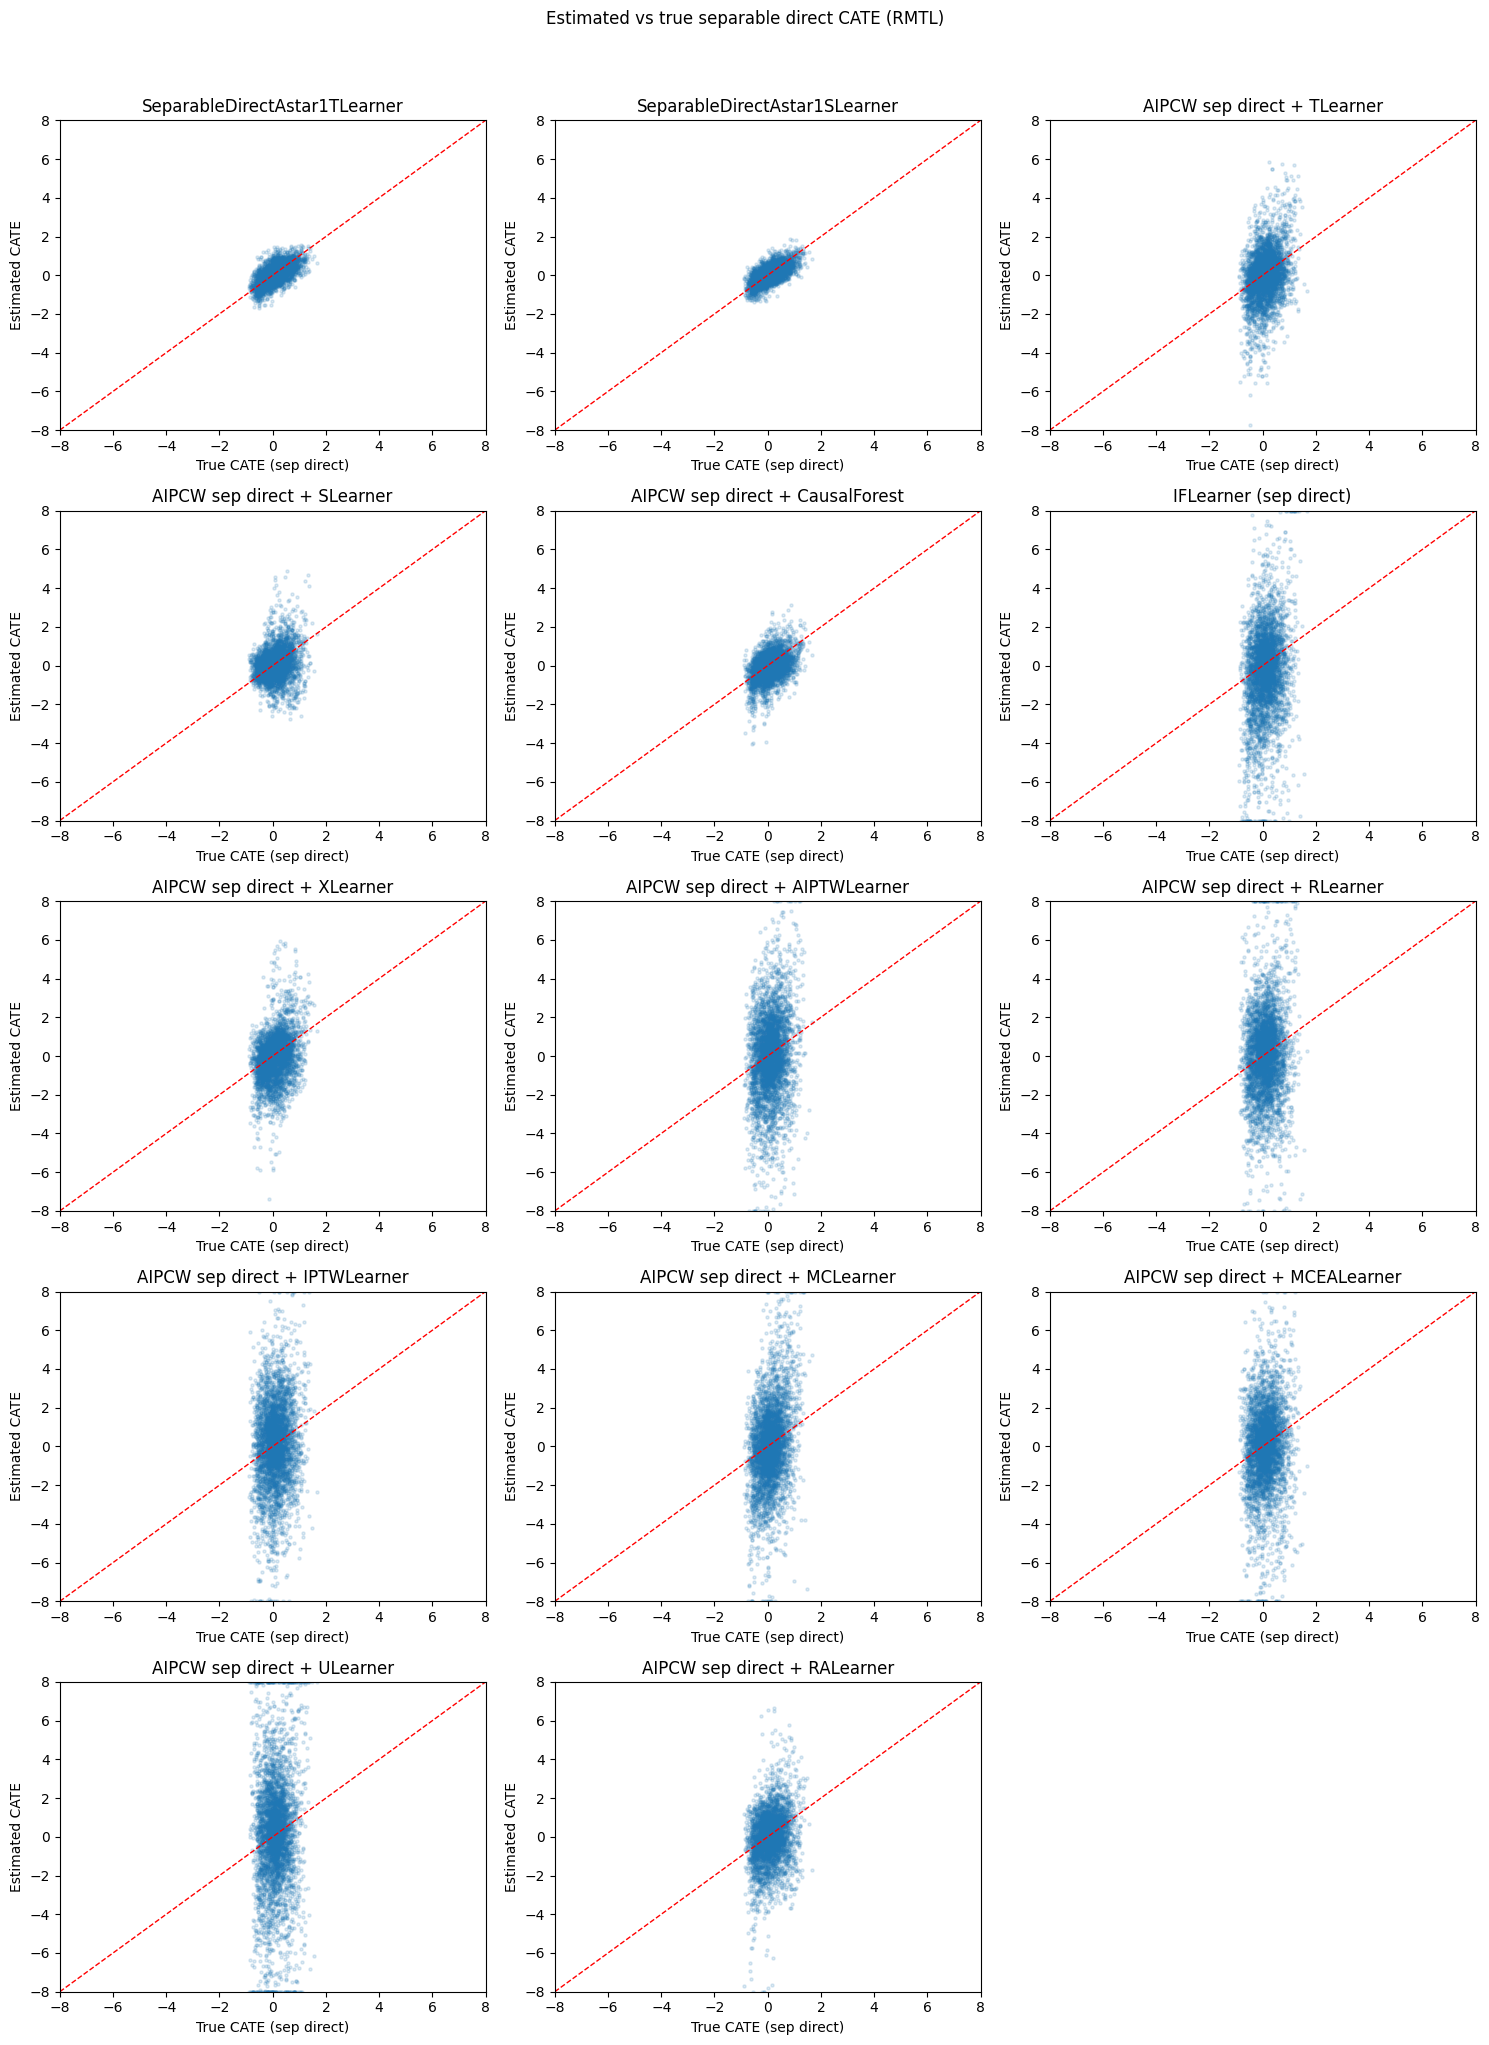

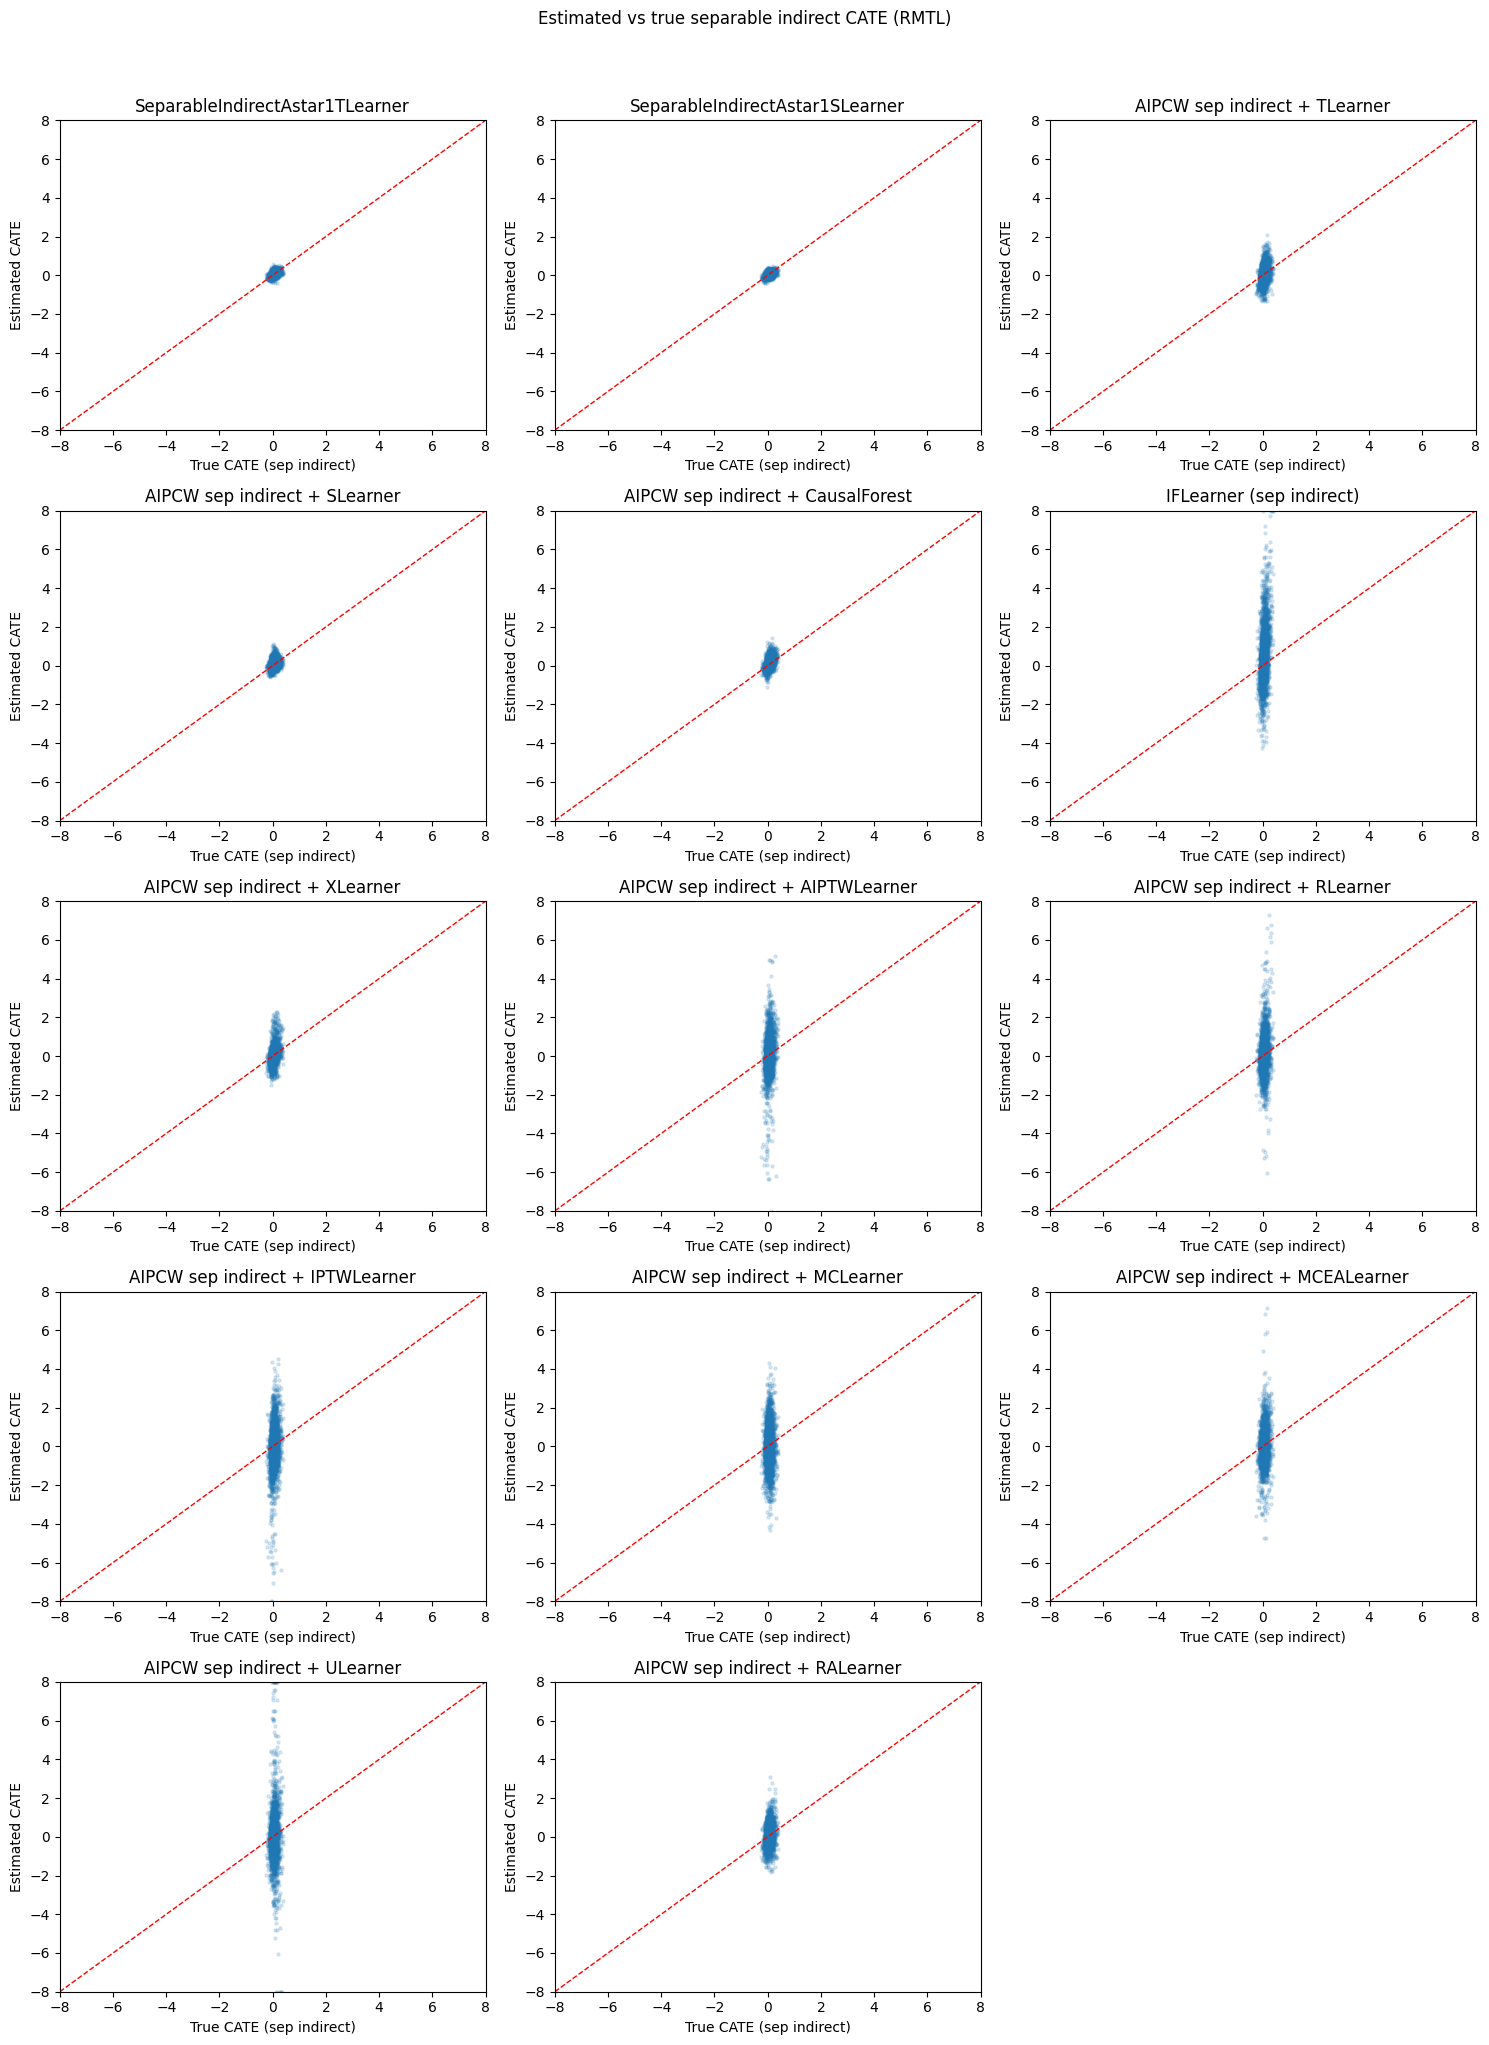

In [13]:
# Scatter plots: estimated CATE vs true CATE for all learners

def _scatter_all(cate_map, truth, title, xlabel):
    names = list(cate_map.keys())
    n_cols = 3
    n_rows = int(np.ceil(len(names) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, names):
        cate_hat = cate_map[name]
        ax.scatter(truth, cate_hat, alpha=0.15, s=5)
        ax.plot(scatter_lims, scatter_lims, 'r--', lw=1)
        ax.set_xlim(scatter_lims)
        ax.set_ylim(scatter_lims)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Estimated CATE')
        ax.set_title(name)

    for ax in axes[len(names):]:
        ax.axis('off')

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


_scatter_all(total_results, true_cate_total,
             'Estimated vs true total CATE (RMTL)',
             'True CATE (total)')
_scatter_all(direct_results, true_cate_direct,
             'Estimated vs true separable direct CATE (RMTL)',
             'True CATE (sep direct)')
_scatter_all(indirect_results, true_cate_indirect,
             'Estimated vs true separable indirect CATE (RMTL)',
             'True CATE (sep indirect)')


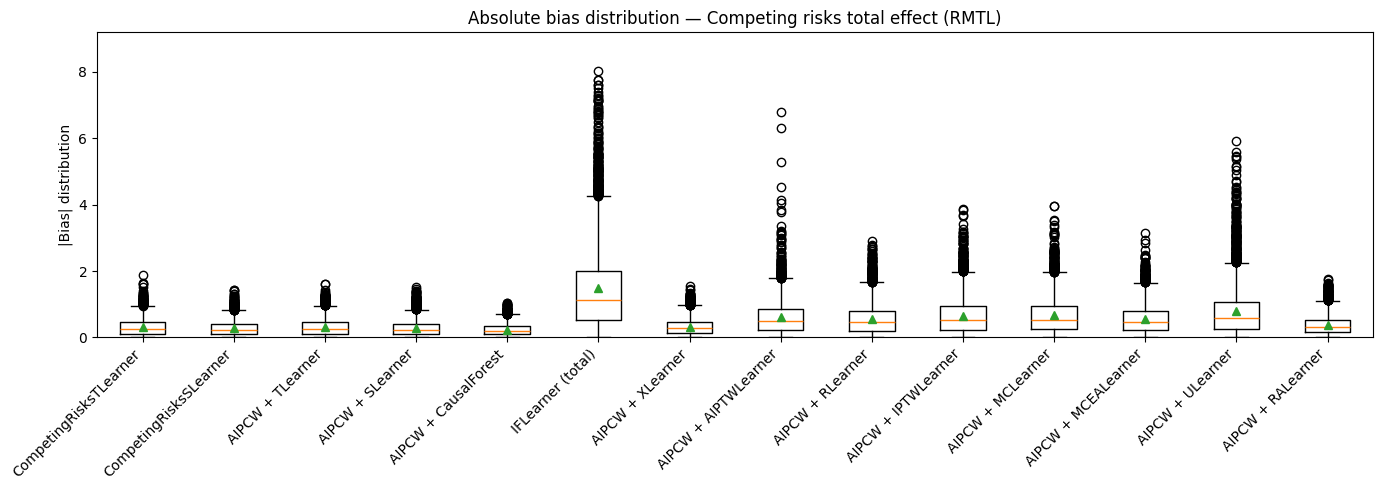

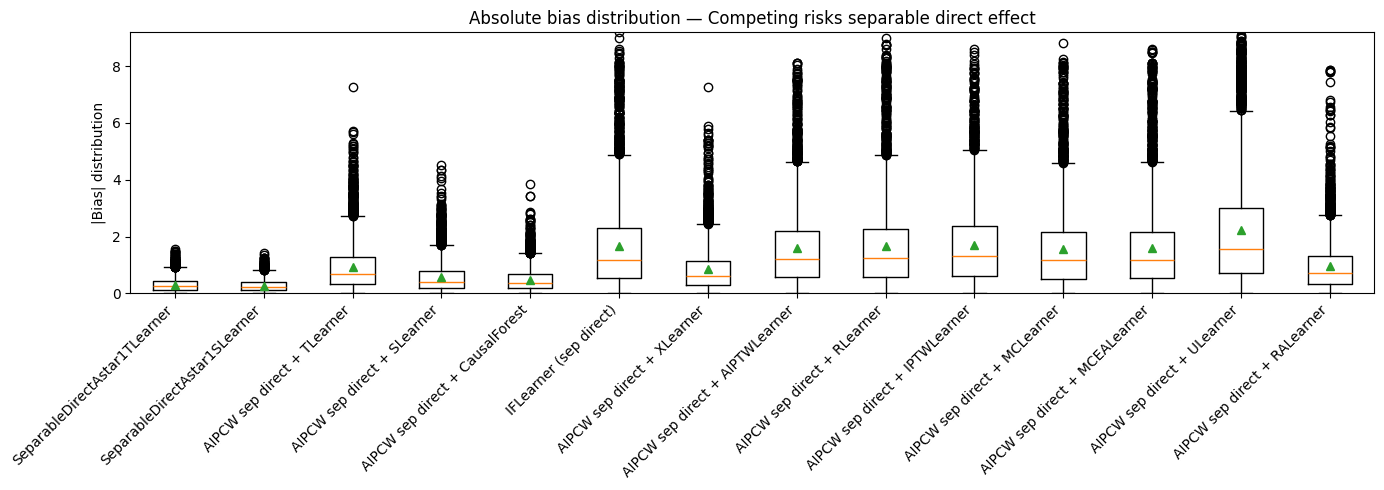

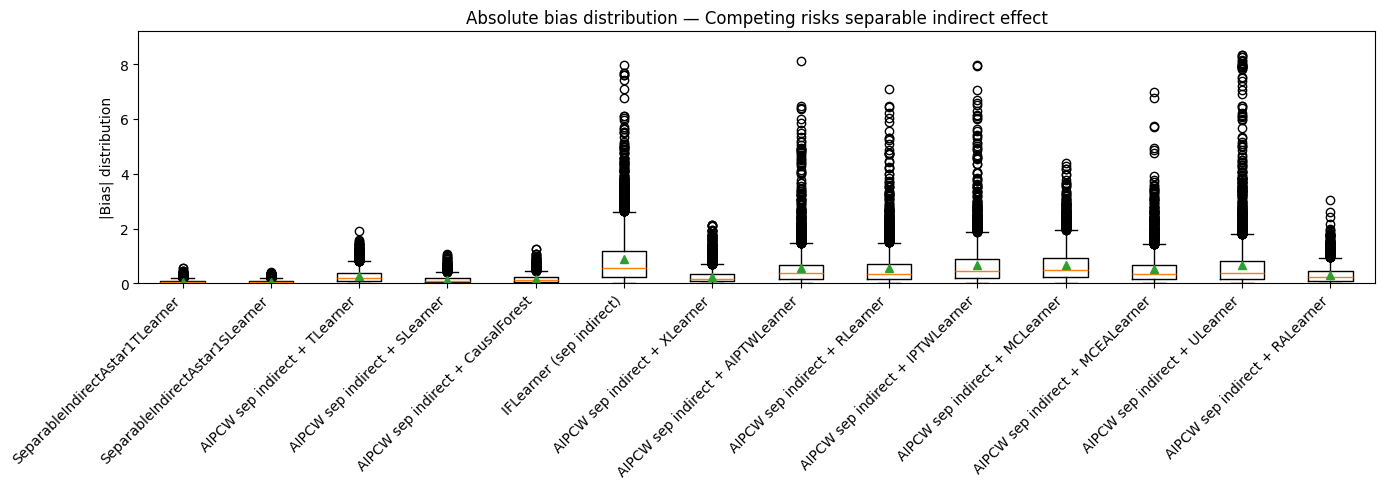

In [14]:
# Boxplots of |bias| and estimated HTE distributions for all learners

def _boxplot_bias(cate_map, truth, title):
    names = list(cate_map.keys())
    biases = [np.abs(cate_map[k] - truth) for k in names]

    plt.figure(figsize=(14, 5))
    plt.boxplot(biases, showmeans=True)
    plt.xlim(*violin_xlim)
    plt.ylim(0.0, violin_ymax)
    plt.xticks(range(1, len(names) + 1), names, rotation=45, ha='right')
    plt.ylabel('|Bias| distribution')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def _boxplot_estimates(cate_map, title):
    names = list(cate_map.keys())
    estimates = [cate_map[k] for k in names]

    plt.figure(figsize=(14, 5))
    plt.boxplot(estimates, showmeans=True)
    plt.xlim(*violin_xlim)
    plt.ylim(estimate_ymin, estimate_ymax)
    plt.xticks(range(1, len(names) + 1), names, rotation=45, ha='right')
    plt.ylabel('Estimated CATE distribution')
    plt.title(title)
    plt.tight_layout()
    plt.show()


_boxplot_bias(total_results, true_cate_total,
              'Absolute bias distribution — Competing risks total effect (RMTL)')
_boxplot_bias(direct_results, true_cate_direct,
              'Absolute bias distribution — Competing risks separable direct effect')
_boxplot_bias(indirect_results, true_cate_indirect,
              'Absolute bias distribution — Competing risks separable indirect effect')


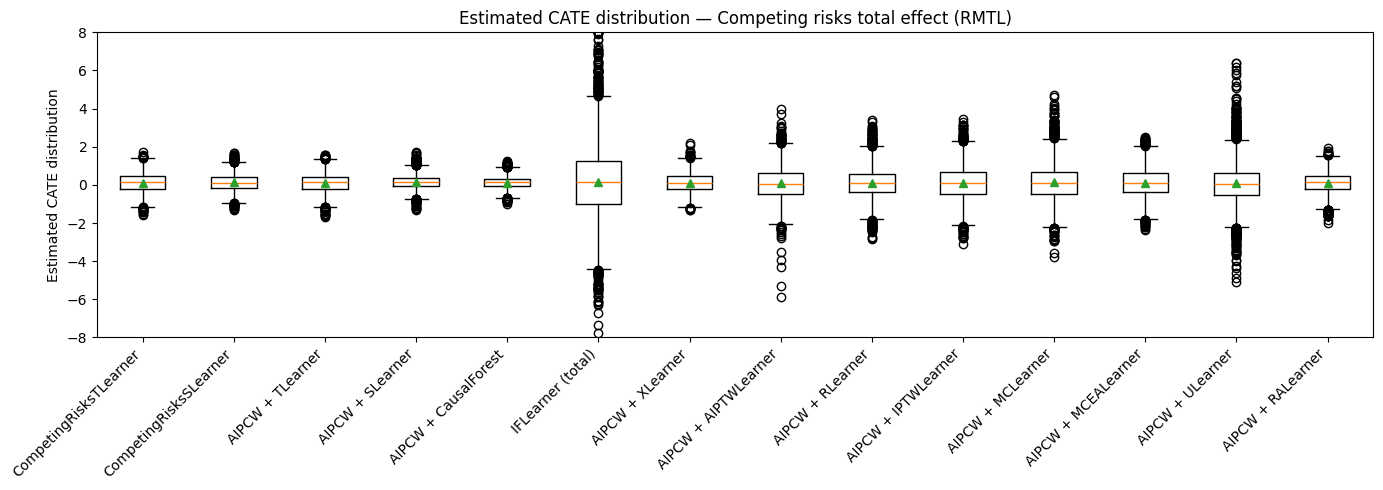

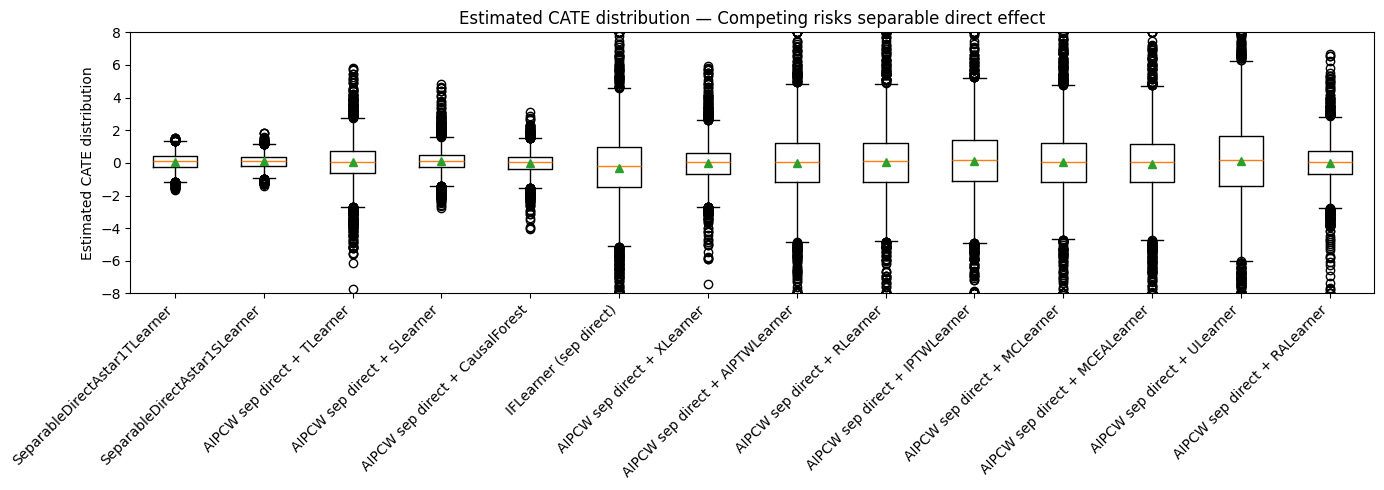

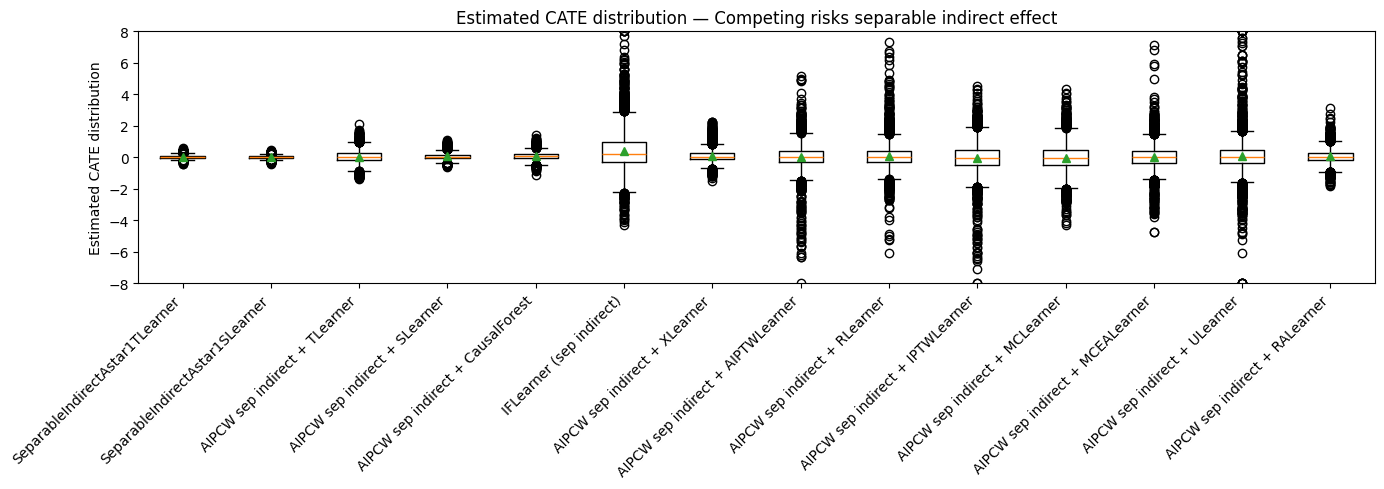

In [15]:
_boxplot_estimates(total_results,
                   'Estimated CATE distribution — Competing risks total effect (RMTL)')
_boxplot_estimates(direct_results,
                   'Estimated CATE distribution — Competing risks separable direct effect')
_boxplot_estimates(indirect_results,
                   'Estimated CATE distribution — Competing risks separable indirect effect')
